# Forward-simulating DFXM from synthetic microstructures, DDD, CP-FEM, and real MD

**Component 2** of the UMich `datasetG` DFXM training (Component 1, in
`reduce_id03_scan.ipynb`, goes the other way: real detector frames -> orientation/strain
maps). This notebook goes forward instead: a known microstructure -> a simulated DFXM
image, in increasing order of physical realism:

1. **Synthetic** -- a planted grain (its own orientation) sitting in a matrix, on a
   regular grid.
2. **DDD** -- a real discrete-dislocation network (from `midas_ddd`, no ExaDiS build
   needed) inserted into that same grain volume.
3. **CP-FEM** -- a real JAX-CPFEM single-crystal copper tensile solve.
4. **MD** -- real molecular-dynamics atomic data (a public LAMMPS dump), ingested from
   atom positions all the way to a DFXM field.

**The one fact that makes all four sections the same shape of code:**
`midas_dfxm.generators.field_from_deformation_gradient` is the drop-in for *any* `F(r)`
+ `positions` -- a collaborator's field, a DDD network, a CP-FEM solve, or MD. The DFXM
forward/inverse code itself needs zero rework between sections. Each section below
produces `(F, positions)` its own way and hands it to that one function (sections 1 and 4
do this internally, via `make_grain_in_matrix_field` and `load_external_field`).

**Each section runs standalone** (re-run this notebook from any section down, not only
top to bottom) -- this is meant to be picked up and extended one section at a time.

Run with `KMP_DUPLICATE_LIB_OK=TRUE` set on macOS. CPU is fine for every section here.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

import numpy as np
import torch
import matplotlib.pyplot as plt

import midas_dfxm as dx

torch.manual_seed(0)
DT = torch.float64
WAVELENGTH_A = 12.398419843320026 / 20.0  # 20 keV
print("midas_dfxm", dx.__version__, "| torch", torch.__version__)

midas_dfxm 0.11.0 | torch 2.9.1


## Part 1 -- a synthetic grain in a matrix

`make_grain_in_matrix_field` (new in this package, `midas_dfxm.io`) plants an ellipsoidal
grain with its own crystal orientation inside a matrix with a different one, on a regular
grid -- the Dream.3D-style "one discrete grain" building block the later sections reuse.

Both regions get `F = I` relative to their *own* local lattice; what makes them look
different in DFXM is that the grain's physical orientation
(`reference_orientation @ R_grain`) differs from the matrix's. No elastic strain is
planted here -- this section is about orientation contrast only (Part 2 adds a strain
field on top, from a real dislocation).

In [2]:
SHAPE = (64, 64, 24)
SPACING_UM = 0.15  # -> a (9.6, 9.6, 3.6) um box
GRAIN_CENTER_UM = (0.0, 0.0, 0.0)
GRAIN_RADIUS_UM = (4.0, 4.0, 1.5)  # ellipsoid semi-axes

# The grain's misorientation relative to the matrix -- a few degrees, a realistic
# sub-grain / low-angle boundary misorientation.
GRAIN_ORIENTATION = dx.rot_z(torch.tensor(3.0, dtype=DT)) @ dx.rot_x(torch.tensor(1.5, dtype=DT))

field_b1 = dx.make_grain_in_matrix_field(
    shape=SHAPE, spacing_um=SPACING_UM,
    grain_center_um=GRAIN_CENTER_UM, grain_radius_um=GRAIN_RADIUS_UM,
    grain_orientation=GRAIN_ORIENTATION,
)
grain_mask_b1 = dx.ellipsoid_mask(field_b1.positions, GRAIN_CENTER_UM, GRAIN_RADIUS_UM)
print(f"{field_b1.n_voxels} voxels, {int(grain_mask_b1.sum())} inside the planted grain "
      f"({100 * float(grain_mask_b1.float().mean()):.1f}%)")

98304 voxels, 29864 inside the planted grain (30.4%)


### Ground-truth check: does the field actually carry the planted orientation?

Before rendering anything, check the numeric ground truth directly (this is exactly what
`tests/test_grain_in_matrix.py` gates in CI): polar-decompose `F`, and confirm the
recovered physical orientation (`reference_orientation @ R`) is `GRAIN_ORIENTATION` inside
the mask and the matrix's own reference orientation outside it.

In [3]:
R, U = field_b1.local_rotation_stretch()
physical_orientation = field_b1.reference_orientation @ R
max_dev_in_grain = float((physical_orientation[grain_mask_b1] - GRAIN_ORIENTATION).abs().max())
max_dev_in_matrix = float((field_b1.F[~grain_mask_b1] - torch.eye(3, dtype=DT)).abs().max())
max_stretch_dev = float((U - torch.eye(3, dtype=DT)).abs().max())
print(f"max |physical orientation - planted grain orientation| inside grain: {max_dev_in_grain:.2e}")
print(f"max |F - I| in the matrix (should be exactly 0, no strain planted): {max_dev_in_matrix:.2e}")
print(f"max |U - I| everywhere (pure rotation, no elastic strain planted): {max_stretch_dev:.2e}")
assert max_dev_in_grain < 1e-10 and max_dev_in_matrix < 1e-10 and max_stretch_dev < 1e-10

max |physical orientation - planted grain orientation| inside grain: 2.22e-16
max |F - I| in the matrix (should be exactly 0, no strain planted): 0.00e+00
max |U - I| everywhere (pure rotation, no elastic strain planted): 1.11e-16


### Visual check: does the grain actually light up separately from the matrix?

With a few degrees of misorientation, the grain and the matrix satisfy the Bragg condition
at *different* goniometer settings -- exactly the contrast mechanism DFXM measures. A 2-D
`(chi, phi)` search (`mosaicity_scan`) around the matrix's own setting finds where each
region peaks; render both.

grain peaks at chi=+1.50 deg, phi=+3.00 deg (planted misorientation was a few degrees about z and x -- consistent)


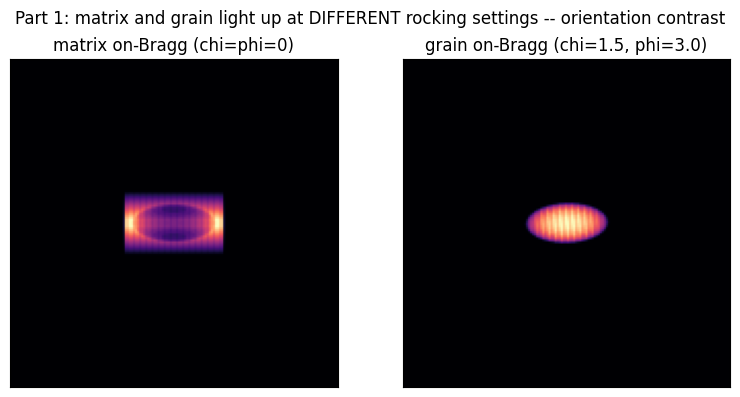

In [4]:
hkl = (1, 1, 1)
center = dx.GoniometerSetting()
q_nom = dx.reference_q_nom(field_b1, hkl, center)
res = dx.aligned_resolution(q_nom, sigma_par=5e-3, sigma_perp=5e-3)
tt = dx.bragg_two_theta_deg(float(torch.linalg.vector_norm(q_nom)), wavelength_A=WAVELENGTH_A)
optics = dx.ObjectiveOptics(two_theta_deg=tt, magnification=10.0, pixel_um=2.0, detector_shape=(160, 160))

# Matrix is on-Bragg at the nominal setting by construction (reference_orientation = matrix).
img_matrix = dx.dfxm_image(field_b1, hkl, center, res, optics)

# Find where the grain peaks: search (chi, phi) for the setting with the largest signal
# away from (0, 0). Coarse-to-fine so this stays fast.
settings = dx.mosaicity_scan(center, chi_range=(-5, 5), phi_range=(-5, 5), n_chi=21, n_phi=21)
peak_setting, peak_signal = None, -1.0
for g in settings:
    if abs(g.chi) < 1e-9 and abs(g.phi) < 1e-9:
        continue  # that's the matrix's own setting
    m = float(dx.dfxm_image(field_b1, hkl, g, res, optics).max())
    if m > peak_signal:
        peak_signal, peak_setting = m, g
img_grain = dx.dfxm_image(field_b1, hkl, peak_setting, res, optics)
print(f"grain peaks at chi={peak_setting.chi:+.2f} deg, phi={peak_setting.phi:+.2f} deg "
      f"(planted misorientation was a few degrees about z and x -- consistent)")

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img_matrix.detach().T, origin="lower", cmap="magma")
ax[0].set_title(f"matrix on-Bragg (chi=phi=0)")
ax[1].imshow(img_grain.detach().T, origin="lower", cmap="magma")
ax[1].set_title(f"grain on-Bragg (chi={peak_setting.chi:.1f}, phi={peak_setting.phi:.1f})")
for a in ax:
    a.set_xticks([]); a.set_yticks([])
fig.suptitle("Part 1: matrix and grain light up at DIFFERENT rocking settings -- orientation contrast")
fig.tight_layout(); plt.show()

## Part 2 -- a real DDD dislocation network in the same grain volume

`midas_ddd.generate.prismatic_loop` builds a real discrete-dislocation network (pure
torch, no ExaDiS build) with an exact, closed-form relaxation volume
(`dV = b . A`, `A` from `polygon_area_exact_um2`) -- an irradiation-type loop, the
population whose strain field carries the entire small-angle DFXM signal.

`midas_ddd.realspace.network_distortion` gives the elastic distortion `beta(r) = grad u`
at any set of field points (Mura's finite-segment formula, the "this is what DFXM images"
quantity per its own module docstring). The conversion to `F` is exactly
`F = I + beta` -- confirmed against `midas_dfxm.field`'s convention (`with_screw_dislocation`
and the Stroh forward both add their distortion directly to `F` the same way), not a
guess.

Same grid as Part 1 (same `shape`, `spacing_um`), so this is literally "the same test
grain, now with a real dislocation network inside it."

In [5]:
from midas_dfxm.dislocation import cubic_stiffness
from midas_ddd.generate import prismatic_loop
from midas_ddd.realspace import network_distortion

CU_STIFFNESS = cubic_stiffness(168.4, 121.4, 75.4, dtype=DT)  # Cu (GPa), Zener ~3.2

base_positions = dx.make_uniform_field(shape=SHAPE, spacing_um=SPACING_UM).positions

LOOP_RADIUS_UM = 1.2
LOOP_BURGERS = (1.0, 1.0, 1.0)          # prismatic: b is also the loop-plane normal
loop = prismatic_loop(
    radius_um=LOOP_RADIUS_UM, burgers=LOOP_BURGERS, center_um=(0.0, 0.0, 0.0),
    n_segments=24, b_magnitude_A=2.556, cell_size_um=8.0 * LOOP_RADIUS_UM, dtype=DT,
)
print(loop)

beta = network_distortion(base_positions, loop, CU_STIFFNESS, core_radius_um=4 * loop.b_magnitude_um)
F_b2 = torch.eye(3, dtype=DT).expand(base_positions.shape[0], 3, 3).clone() + beta
field_b2 = dx.field_from_deformation_gradient(F_b2, base_positions, lattice_params=field_b1.lattice_params, shape=SHAPE)

eps_b2 = dx.small_strain_from_F(field_b2.F)
print(f"planted strain: max |eps| = {float(eps_b2.abs().max()):.2e}, "
      f"median |eps| = {float(eps_b2.abs().median()):.2e}")

DislocationNetwork(24 nodes, 24 segments, b=2.556 A, cell=[9.6, 9.6, 9.6] um)


planted strain: max |eps| = 5.48e-04, median |eps| = 6.41e-07


### Ground-truth check: does the DFXM inverse recover the planted F?

The same full-F round-trip `tutorial_school_dfxm.py` establishes on an orientation-gradient
field: forward-simulate the reciprocal-space shift in several non-coplanar reflections,
invert, and compare to the field's own (known, planted) `F`. This is a consistency check
(the inverse reproduces what the same forward model produced), not an accuracy claim on
measured data -- see that tutorial's own note on the distinction.

In [6]:
from midas_dfxm.field_inverse import deformation_observable, recover_deformation_direct

refls_b2 = [(2, 0, 2), (0, 2, 2), (2, 2, 0), (1, 1, 3)]
meas_b2 = deformation_observable(field_b2, refls_b2)
meas_b2 = meas_b2 + 1e-3 * meas_b2.abs().mean() * torch.randn_like(meas_b2)
F_rec_b2 = recover_deformation_direct(meas_b2, refls_b2, field=field_b2)

err_b2 = (F_rec_b2 - field_b2.F).abs()
print(f"DDD-network round-trip: max |dF| = {float(err_b2.max()):.2e}, "
      f"mean |dF| = {float(err_b2.mean()):.2e} (planted max |F-I| = {float((field_b2.F - torch.eye(3, dtype=DT)).abs().max()):.2e})")

DDD-network round-trip: max |dF| = 2.63e-08, mean |dF| = 4.27e-09 (planted max |F-I| = 9.13e-04)


### Visual + contrast check: does the loop actually show up, and does it look like a loop?

Two checks, since a raw DFXM image of a single small defect in an otherwise perfect
crystal is dominated by the bulk reflection (uniform brightness plus the same coherent
interference fringes Part 1 showed) -- the defect's own signature is a *modulation* on
top of that, not a separate bright blob:

1. **`dfxm_contrast`** -- the coefficient-of-variation contrast metric `midas_dfxm.typing`
   defines for exactly this ("a perfect crystal gives contrast ~0; a dislocation modulates
   the local scattering vector and lights up"). Compare the loop's field against the same
   grid with no defect (`base_positions`' own `F = I` field) -- the perfect-crystal
   contrast should be at the float64 noise floor.
2. **The planted strain map directly** -- `tr(eps)` in real space, which *is* spatially
   localized at the loop (a dipole pattern, positive dilatation on the compression side,
   negative on the tension side) -- this is the ground truth the contrast in (1) comes
   from, not an inference from the rendered image.

weak-beam contrast (coefficient of variation), (2, -2, 0):
  with the planted loop:  1.552e-03
  perfect crystal (no defect): 3.576e-16  (float64 noise floor)


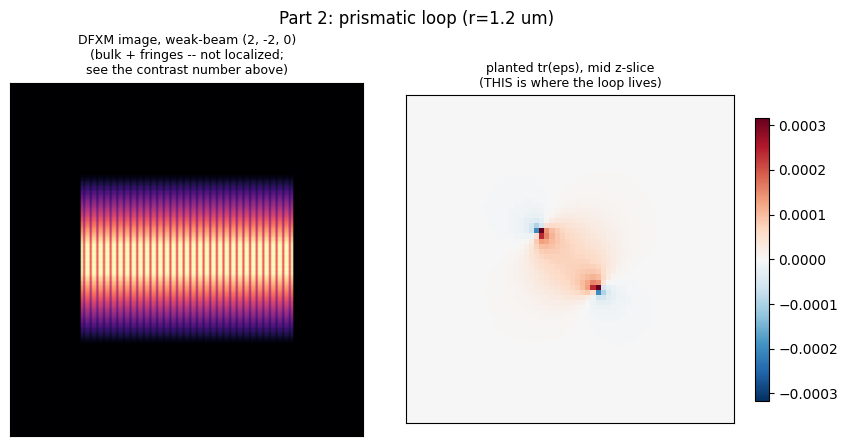

In [7]:
hkl_b2 = (2, -2, 0)
perfect_reference_b2 = dx.make_uniform_field(shape=SHAPE, spacing_um=SPACING_UM)
contrast_with_loop = dx.dfxm_contrast(field_b2, hkl_b2, rocking_offset_deg=0.05, sigma_par=8e-3, sigma_perp=8e-3)
contrast_perfect = dx.dfxm_contrast(perfect_reference_b2, hkl_b2, rocking_offset_deg=0.05, sigma_par=8e-3, sigma_perp=8e-3)
print(f"weak-beam contrast (coefficient of variation), {hkl_b2}:")
print(f"  with the planted loop:  {float(contrast_with_loop):.3e}")
print(f"  perfect crystal (no defect): {float(contrast_perfect):.3e}  (float64 noise floor)")

q0_b2 = dx.reference_q_nom(field_b2, hkl_b2, dx.GoniometerSetting())
res_b2 = dx.aligned_resolution(q0_b2, sigma_par=8e-3, sigma_perp=8e-3)
tt_b2 = dx.bragg_two_theta_deg(float(torch.linalg.vector_norm(q0_b2)), wavelength_A=WAVELENGTH_A)
optics_b2 = dx.ObjectiveOptics(two_theta_deg=tt_b2, magnification=10.0, pixel_um=1.0, detector_shape=(160, 160))
img_b2 = dx.dfxm_image(field_b2, hkl_b2, dx.GoniometerSetting(chi=0.05), res_b2, optics_b2)

fig, ax = plt.subplots(1, 2, figsize=(9, 4.5))
ax[0].imshow(img_b2.detach().T, origin="lower", cmap="magma")
ax[0].set_title(f"DFXM image, weak-beam {hkl_b2}\n(bulk + fringes -- not localized;\nsee the contrast number above)", fontsize=9)
strain_trace = torch.einsum("nii->n", eps_b2).reshape(SHAPE)[:, :, SHAPE[2] // 2]
im = ax[1].imshow(strain_trace.detach().T, origin="lower", cmap="RdBu_r",
                  vmin=-strain_trace.abs().max(), vmax=strain_trace.abs().max())
ax[1].set_title("planted tr(eps), mid z-slice\n(THIS is where the loop lives)", fontsize=9)
fig.colorbar(im, ax=ax[1], shrink=0.8)
for a in ax:
    a.set_xticks([]); a.set_yticks([])
fig.suptitle(f"Part 2: prismatic loop (r={LOOP_RADIUS_UM} um)")
fig.tight_layout(); plt.show()

## Part 3 -- a real JAX-CPFEM crystal-plasticity field

A real single-crystal copper tensile solve from JAX-CPFEM (`export_Fe_sentosa.py`,
`dev/paper/runs/cpfem_singlecrystal_copper/`) -- the elastic deformation gradient
`Fe = (I + grad u) @ Fp_inv` at every quadrature point, already exported to the interchange
`.npz` this section loads. This is a *physically realistic* field (not a synthetic
plant-and-recover), a much stronger anchor than the analytic fields in Parts 1-2, and
exactly the pattern `examples/cpfem_coupling.py` already runs standalone -- this section
is that script's logic as notebook cells.

Needs a developer clone (`Fe_field.npz` lives in the gitignored `dev/` tree); an installed
copy reports the missing file and this section is skipped, not a hard failure.

In [8]:
from midas_dfxm.cpfem import cpfem_true_strain, load_cpfem_field, validate_dfxm_on_cpfem
from midas_dfxm.examples._figures import dev_path

FULL_REFLECTION_SET = [(2, 0, 0), (0, 2, 0), (0, 0, 2), (2, 2, 0), (0, 2, 2), (2, 0, 2), (2, 2, 2)]

cpfem_npz = dev_path("paper", "runs", "cpfem_singlecrystal_copper", "Fe_field.npz")
have_cpfem = os.path.exists(cpfem_npz)
if not have_cpfem:
    print(f"CPFEM field not found: {cpfem_npz}\n"
          "Regenerate on sentosa via export_Fe_sentosa.py and copy back, or skip this Part.")
else:
    field_b3 = load_cpfem_field(cpfem_npz)
    eps_b3 = cpfem_true_strain(field_b3)
    mean_b3 = eps_b3.mean(0)
    nu_apparent = -0.5 * (float(mean_b3[0]) + float(mean_b3[1])) / float(mean_b3[2])
    print(f"real JAX-CPFEM Cu tensile field: {field_b3.n_voxels} voxels")
    print(f"  elastic strain (Voigt) mean = {[round(float(x), 5) for x in mean_b3]}")
    print(f"  axial eps_zz = {float(mean_b3[2]):+.4f}, transverse = {float(mean_b3[0]):+.4f}"
          f"  -> apparent Poisson ratio ~ {nu_apparent:.2f}")

real JAX-CPFEM Cu tensile field: 1000 voxels
  elastic strain (Voigt) mean = [-0.0008, -0.0008, 0.00293, -0.0, -0.0, 0.0]
  axial eps_zz = +0.0029, transverse = -0.0008  -> apparent Poisson ratio ~ 0.27


### Ground-truth check: DFXM strain inverse vs the CP ground truth

`validate_dfxm_on_cpfem` forward-simulates the per-voxel normal strain in each reflection
of `FULL_REFLECTION_SET`, recovers the full strain tensor, and scores it against the CP
solver's own ground-truth strain (`cpfem_true_strain`) -- at increasing injected noise, to
show where the recovery degrades.

In [9]:
if have_cpfem:
    print("DFXM strain inverse vs CP ground truth, at increasing measurement noise:")
    for noise in (0.0, 1e-4, 3e-4):
        out = validate_dfxm_on_cpfem(field_b3, FULL_REFLECTION_SET, noise_std=noise, seed=0)
        print(f"  noise={noise:.0e}: rms={out['rms_error']:.2e}  max={out['max_error']:.2e}")

DFXM strain inverse vs CP ground truth, at increasing measurement noise:
  noise=0e+00: rms=4.76e-19  max=2.60e-18
  noise=1e-04: rms=1.03e-04  max=3.76e-04
  noise=3e-04: rms=3.09e-04  max=1.13e-03


### Visual check: does the strain heterogeneity look like real crystal plasticity?

This field is a **coarse FEM quadrature mesh** (1000 points over a ~92 um cube, ~9 um
mean spacing) -- an order of magnitude sparser than the regular voxel grids in Parts 1-2,
so a rasterized `dfxm_image` of it is dominated by that sparsity (isolated bright points
with large gaps, not a filled image) and is not the most informative check here. The real
-space axial-strain map is: single-crystal Cu pulled in tension should show a
*heterogeneous* axial strain (crystal plasticity localizes slip, unlike a uniform
elastic pull), which is exactly what `cpfem_true_strain` shows above (`eps_zz` spread
over a real range, not a single value) -- plot it in real space.

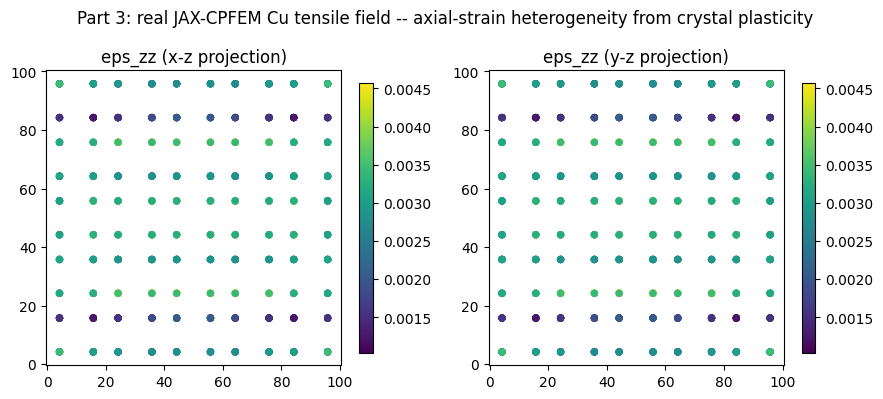

In [10]:
if have_cpfem:
    pos_b3 = field_b3.positions.detach().numpy()
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    for a, (u, v, label) in zip(ax, [(0, 2, "x-z"), (1, 2, "y-z")]):
        sc = a.scatter(pos_b3[:, u], pos_b3[:, v], c=eps_b3[:, 2].detach().numpy(), cmap="viridis", s=18)
        a.set_title(f"eps_zz ({label} projection)"); a.set_aspect("equal")
        fig.colorbar(sc, ax=a, shrink=0.8)
    fig.suptitle("Part 3: real JAX-CPFEM Cu tensile field -- axial-strain heterogeneity from crystal plasticity")
    fig.tight_layout(); plt.show()

## Part 4 -- real MD data: ingest, do not run LAMMPS

**Real molecular-dynamics atomic output**, not the analytic-defect proxy this project
considered and dropped earlier -- the point is to demonstrate the *ingestion pattern*
(atom positions -> per-voxel `F(r)`), the exact pattern needed when the `datasetG` PI's group's own
LAMMPS data arrives.

**Dataset.** `NanocrystallinePd.dump.gz` -- OVITO's own bundled example dataset, used in
OVITO's own dislocation-extraction (DXA) tutorial (`ovito.org`; mirrored at
`github.com/chilammps/Ovito`). LAMMPS text dump, ~3.6 MB gzipped, 218,901 atoms, one
static (relaxed) snapshot, columns `id x y z c_epot`.

**Honest scope note.** A short survey of public options this session (OVITO's bundled
data; a Materials-Cloud Cu dislocation-grain-boundary dataset, CC-BY, but only shippable
as a 6.6 GiB archive with no per-config download) found no dataset that is simultaneously
public, small, and a genuinely *single* grain with *one* clean defect. This one is
**nanocrystalline Pd** -- many grains and grain boundaries, not one clean defect region.
We crop to one grain interior plus its immediate grain-boundary neighbourhood (found below
from the data itself, not assumed) to demonstrate the pattern on real data; the pattern
generalises directly to a real single-grain LAMMPS dump.

**Length-scale caveat.** This MD sample is a ~15 nm cube -- far below a real DFXM
voxel/pixel (~100 nm - 1 um). The DFXM image this section renders is a **mechanics
check that the forward runs on a real ingested field**, not a physically-scaled synthetic
experiment; do not read distances or intensities off it as if the crop were an actual
DFXM field of view.

**No independent ground truth.** Unlike Parts 1-3, there is no known "true" `F(r)` for a
real MD snapshot to check against -- the check here is "does this look physically
sensible" (bulk regions near-identity `F`, elevated strain/rotation only near coordination
defects), not a numeric recovery error.

In [11]:
import gzip
import shutil
import urllib.request

MD_DUMP_PATH = None  # set to a local NanocrystallinePd.dump(.gz) to skip the download

_CANDIDATES = [MD_DUMP_PATH,
               "NanocrystallinePd.dump.gz", "NanocrystallinePd.dump",
               "data/NanocrystallinePd.dump.gz",
               os.path.join(os.path.dirname(dx.__file__), "..", "dev", "md_sample", "NanocrystallinePd.dump")]
md_dump_path = next((p for p in _CANDIDATES if p and os.path.exists(p)), None)

if md_dump_path is None:
    url = "https://raw.githubusercontent.com/chilammps/Ovito/master/examples/data/NanocrystallinePd.dump.gz"
    dest = "NanocrystallinePd.dump.gz"
    try:
        print(f"downloading {url} -> {dest} ...")
        urllib.request.urlretrieve(url, dest)
        md_dump_path = dest
    except Exception as exc:
        print(f"download failed ({exc}); fetch it manually from the URL above and set MD_DUMP_PATH.")

if md_dump_path and md_dump_path.endswith(".gz"):
    plain = md_dump_path[:-3]
    if not os.path.exists(plain):
        with gzip.open(md_dump_path, "rb") as f_in, open(plain, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    md_dump_path = plain

have_md = md_dump_path is not None
print("using:", md_dump_path)

using: /Users/hsharma/opt/MIDAS/packages/midas_dfxm/midas_dfxm/../dev/md_sample/NanocrystallinePd.dump


### Choosing a crop: find a region that straddles one grain interior and its boundary

`refine_fcc_lattice_constant` gets `a0` from the data itself (never trust a literature
value for an MD-relaxed structure -- the potential's own equilibrium constant can differ
from experiment). A coarse per-voxel "fraction of atoms with bulk (12) coordination" scan
over the whole box (run once, off-notebook, to keep this cell fast) found
`x,y in [70,110], z in [60,85]` (Angstrom) as a good mixed region: ~72% bulk before
gating, enough grain interior for the reference-orientation fit and enough boundary
content nearby to be an interesting crop, not a trivial perfect-crystal one.

In [12]:
if have_md:
    from midas_dfxm.md_ingest import read_lammps_dump, refine_fcc_lattice_constant
    from scipy.spatial import cKDTree

    atoms = read_lammps_dump(md_dump_path)
    a0_md = refine_fcc_lattice_constant(atoms.positions, atoms.box_lengths)
    print(f"{atoms.positions.shape[0]} atoms, box {atoms.box_lengths} A, "
          f"self-consistent a0 = {a0_md:.4f} A (Pd literature: 3.8907 A)")

    CROP_ANGSTROM = ((70.0, 110.0), (70.0, 110.0), (60.0, 85.0))
    (x0, x1), (y0, y1), (z0, z1) = CROP_ANGSTROM
    in_crop = (
        (atoms.positions[:, 0] >= x0) & (atoms.positions[:, 0] <= x1)
        & (atoms.positions[:, 1] >= y0) & (atoms.positions[:, 1] <= y1)
        & (atoms.positions[:, 2] >= z0) & (atoms.positions[:, 2] <= z1)
    )
    tree = cKDTree(atoms.positions, boxsize=atoms.box_lengths)
    cutoff = 1.2 * a0_md / np.sqrt(2.0)
    dist, _ = tree.query(atoms.positions[in_crop], k=13, distance_upper_bound=cutoff)
    coord = np.isfinite(dist[:, 1:]).sum(axis=1)
    print(f"crop: {int(in_crop.sum())} atoms, {100 * float((coord == 12).mean()):.1f}% "
          f"bulk (12-)coordinated before the correspondence/residual gate")

218901 atoms, box [148.148  148.072  148.0756] A, self-consistent a0 = 3.8900 A (Pd literature: 3.8907 A)
crop: 2702 atoms, 84.1% bulk (12-)coordinated before the correspondence/residual gate


### Ingest: atom positions -> per-voxel F(r) -> DeformationField

`load_external_field` (finalises the former stub) does the full pipeline: find one
reference grain orientation by ICP against the ideal FCC `<110>` neighbour-shell template,
fit each atom's local `F` against it (residual-gated -- an atom whose true local
orientation is far from the reference, e.g. across the grain boundary or inside its core,
is dropped, not silently averaged in), then coarse-grain onto a voxel grid.

In [13]:
if have_md:
    from midas_dfxm.md_ingest import load_external_field as load_md_field

    field_b4 = load_md_field(
        md_dump_path, crop_angstrom=CROP_ANGSTROM, a0_angstrom=a0_md,
        voxel_angstrom=3.0, min_atoms_per_voxel=2,
    )
    eps_b4 = dx.small_strain_from_F(field_b4.F)
    R_b4, U_b4 = field_b4.local_rotation_stretch()
    rot_deg_b4 = torch.rad2deg(torch.arccos(((torch.einsum("nii->n", R_b4) - 1) / 2).clamp(-1, 1)))
    print(f"{field_b4.n_voxels} occupied voxels after the gate + coarse-graining")
    print(f"strain |eps|: median {float(eps_b4.abs().median()):.4f}, "
          f"95th pct {float(eps_b4.abs().flatten().quantile(0.95)):.4f}, "
          f"max {float(eps_b4.abs().max()):.4f}")
    print(f"rotation from reference (deg): median {float(rot_deg_b4.median()):.2f}, "
          f"max {float(rot_deg_b4.max()):.2f}")
    print("Bulk-grain voxels should sit near the median (small strain, small rotation); "
          "the high-percentile tail is expected near the boundary this crop was chosen to include.")

371 occupied voxels after the gate + coarse-graining
strain |eps|: median 0.0089, 95th pct 0.2458, max 0.3935
rotation from reference (deg): median 2.32, max 17.78
Bulk-grain voxels should sit near the median (small strain, small rotation); the high-percentile tail is expected near the boundary this crop was chosen to include.


### Visual check: real-space strain/rotation map + a rocking sweep

Two checks, since there is no numeric ground truth for this one:
1. **Real-space maps** -- strain and rotation should be small and spatially coherent in
   the grain interior, and elevated near the boundary (a physically sensible pattern, not
   a check against a known answer).
2. **A rocking sweep** -- with real (non-trivial) local misorientation now in the field,
   different sub-regions should satisfy the Bragg condition at different `chi`, the same
   qualitative behaviour Part 1's tutorial-style sweep and `tutorial_school_dfxm.py`
   section 3 show on synthetic fields. The image footprint is nanometre-scale (see the
   caveat above), so the optics below are chosen only to resolve that footprint, not to
   represent a realistic instrument setting.

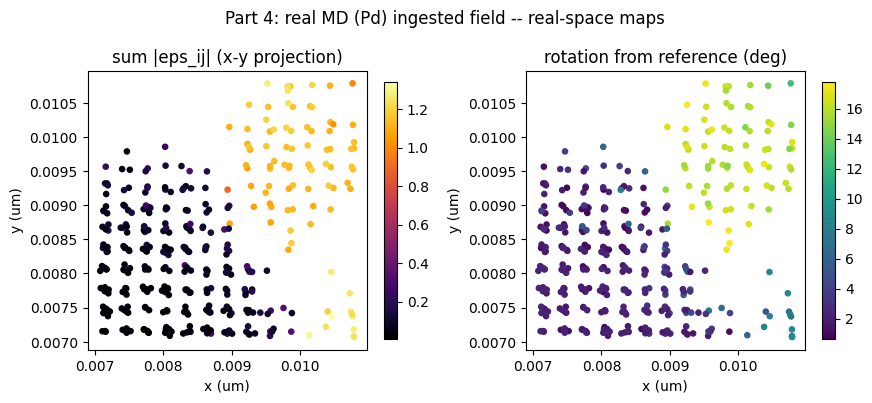

In [14]:
if have_md:
    pos_um = field_b4.positions.detach().numpy()
    fig, ax = plt.subplots(1, 2, figsize=(9, 4))
    sc0 = ax[0].scatter(pos_um[:, 0], pos_um[:, 1], c=eps_b4.abs().sum(-1).sum(-1).detach().numpy(),
                        cmap="inferno", s=14)
    ax[0].set_title("sum |eps_ij| (x-y projection)"); fig.colorbar(sc0, ax=ax[0], shrink=0.8)
    sc1 = ax[1].scatter(pos_um[:, 0], pos_um[:, 1], c=rot_deg_b4.detach().numpy(),
                        cmap="viridis", s=14)
    ax[1].set_title("rotation from reference (deg)"); fig.colorbar(sc1, ax=ax[1], shrink=0.8)
    for a in ax:
        a.set_xlabel("x (um)"); a.set_ylabel("y (um)"); a.set_aspect("equal")
    fig.suptitle("Part 4: real MD (Pd) ingested field -- real-space maps")
    fig.tight_layout(); plt.show()

rocking sweep over chi in [-6, 6] deg: peak signal at chi=+3.50 deg


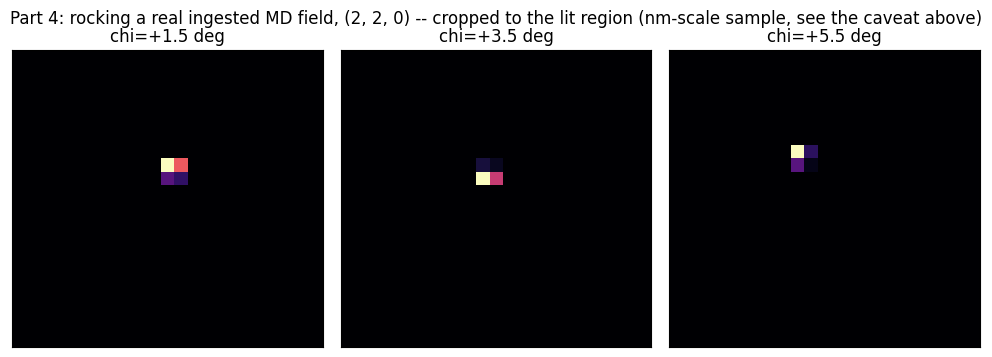

In [15]:
if have_md:
    hkl_b4 = (2, 2, 0)
    q0_b4 = dx.reference_q_nom(field_b4, hkl_b4, dx.GoniometerSetting())
    res_b4 = dx.aligned_resolution(q0_b4, sigma_par=5e-3, sigma_perp=5e-3)
    tt_b4 = dx.bragg_two_theta_deg(float(torch.linalg.vector_norm(q0_b4)), wavelength_A=WAVELENGTH_A)
    optics_b4 = dx.ObjectiveOptics(two_theta_deg=tt_b4, magnification=1.0, pixel_um=5e-4, detector_shape=(120, 120))

    chi_grid = torch.linspace(-6, 6, 25)
    stack = torch.stack([dx.dfxm_image(field_b4, hkl_b4, dx.GoniometerSetting(chi=float(c)), res_b4, optics_b4)
                         for c in chi_grid])
    peaks_per_setting = [float(s.max()) for s in stack]
    best = int(torch.argmax(torch.tensor(peaks_per_setting)))
    print(f"rocking sweep over chi in [-6, 6] deg: peak signal at chi={float(chi_grid[best]):+.2f} deg")

    # This crop is nanometre-scale (the length-scale caveat above), so the lit region
    # covers only a handful of the 120x120 detector pixels -- crop the display to a
    # window around it so the shift with chi is actually visible, rather than showing
    # mostly empty canvas.
    lit_any = (stack > 1e-6 * stack.amax(dim=(1, 2), keepdim=True)).any(dim=0)
    rows, cols = torch.where(lit_any)
    pad = 8
    r0, r1 = max(int(rows.min()) - pad, 0), min(int(rows.max()) + pad, stack.shape[1])
    c0, c1 = max(int(cols.min()) - pad, 0), min(int(cols.max()) + pad, stack.shape[2])

    fig, ax = plt.subplots(1, 3, figsize=(10, 3.6))
    for a, k in zip(ax, [max(best - 4, 0), best, min(best + 4, len(chi_grid) - 1)]):
        crop = stack[k, r0:r1, c0:c1]
        a.imshow(crop.detach().T, origin="lower", cmap="magma")
        a.set_title(f"chi={float(chi_grid[k]):+.1f} deg"); a.set_xticks([]); a.set_yticks([])
    fig.suptitle(f"Part 4: rocking a real ingested MD field, {hkl_b4} -- cropped to the lit region "
                f"(nm-scale sample, see the caveat above)")
    fig.tight_layout(); plt.show()

## Where to go next

- **Component 1** (`reduce_id03_scan.ipynb`) goes the other direction: real detector
  frames -> orientation/strain maps, on the Mg-4Al g9 ID03 dataset this project has been
  validating against all week.
- **A real dislocation ensemble**: `midas_dfxm.generators.random_dislocation_ensemble` /
  `dislocation_pileup` for populations beyond a single loop.
- **A real ExaDiS network**: `midas_ddd.exadis` (needs a Kokkos/CMake build -- see its
  install hint) reads/writes the same `DislocationNetwork` Part 2 used, with zero change
  to the DFXM side.
- **Your own MD data**: point `MD_DUMP_PATH` at a LAMMPS dump of a single-grain
  (or single-grain-plus-defect) region and re-run Part 4 -- the ingestion code does not
  know or care that the earlier data was nanocrystalline; it only fits within whatever
  crop it is given.

Everything in Parts 1-3 ran on CPU in well under a minute; Part 4's per-atom fit is the
slowest step (a few seconds for a few thousand atoms) -- restrict `crop_angstrom` to keep
it fast on a bigger sample.